# Steady state noise of the SOX2/NANOG monomer model


In [13]:
import numpy as np
import seaborn as sns
import seaborn as sns
from matplotlib import pyplot as plt

# mRNA parameters
mean_burst_size = 5
b_y = np.random.default_rng().geometric(p=1/mean_burst_size, size = 1) 
gamma_y = 0.0001389 # degradation       
k_y0 = 0.0027 # burst frequency

# SOX2 parameters
beta_s = 0.06       
alpha_s = 0.5      
S_tot = 9        
k_ys = 1.0          
N_S = 2
# NANOG parameters
alpha_n = 0.3      
beta_n = 0.2        
N_tot = 1
k_yn = 1.0                 
N_N = 10           



In [17]:
def calculate_target_fano(alpha_n = 0.3, alpha_s = 0.5, beta_n = 0.2, beta_s = 0.06, N_N = 10, N_S = 2, N_tot = 9, S_tot = 1):
    p_s = (alpha_s * N_S) / (alpha_s * N_S + beta_s)
    var_s = S_tot * p_s * (1.0 - p_s)
    
    p_n = (alpha_n * N_N) / (alpha_n * N_N + beta_n)
    var_n = N_tot * p_n * (1.0 - p_n)
    
    mean_fy = k_y0 + (k_ys * S_tot * p_s) + (k_yn * N_tot * p_n)
    
    intrinsic = 1.0 + b_y
    
    ext_s = (b_y / mean_fy) * ( (k_ys**2 * var_s) / (gamma_y + alpha_s * N_S + beta_s) )
    ext_n = (b_y / mean_fy) * ( (k_yn**2 * var_n) / (gamma_y + alpha_n * N_N + beta_n) )
    
    return intrinsic + ext_s + ext_n


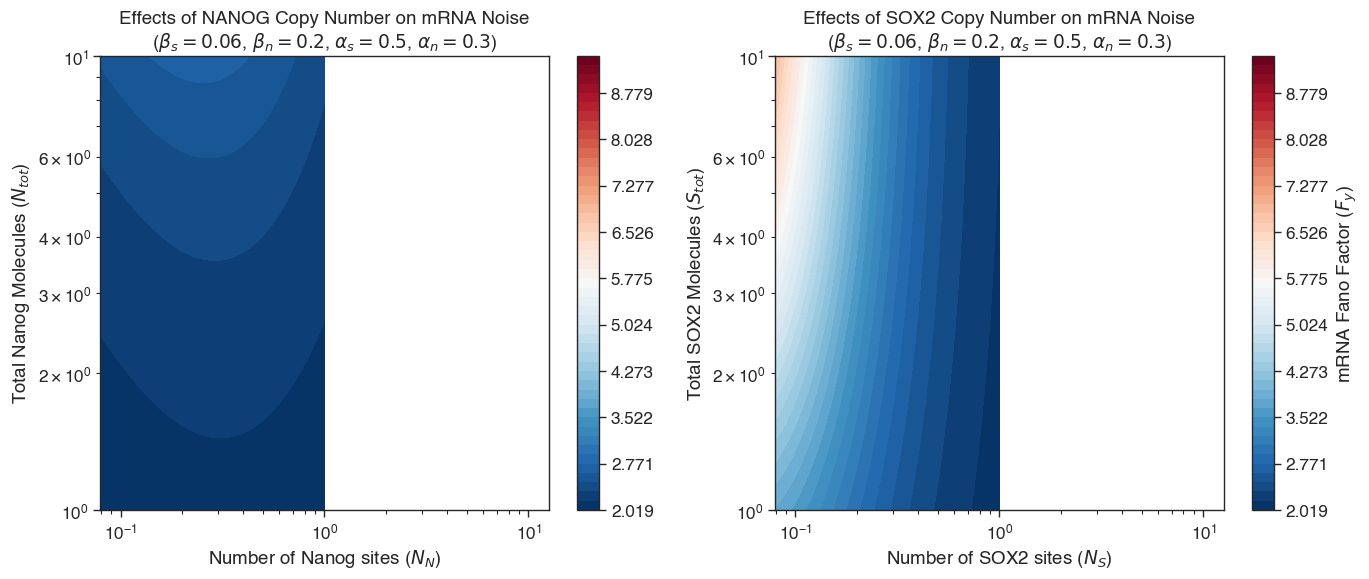

In [131]:
NN_vals = np.linspace(0.0, 1.0, 200)
Ntot_vals = np.logspace(0, 1, 200)
X_NN, Y_Ntot = np.meshgrid(NN_vals, Ntot_vals)

Fy_grid_nanog = calculate_target_fano(N_N=X_NN, N_tot=Y_Ntot, S_tot=S_tot)
Fy_grid_sox2 = calculate_target_fano(N_S=X_NN, S_tot=Y_Ntot, N_tot=N_tot)

vmin = min(np.min(Fy_grid_nanog), np.min(Fy_grid_sox2))
vmax = max(np.max(Fy_grid_nanog), np.max(Fy_grid_sox2))
shared_levels = np.linspace(vmin, vmax, 50)

sns.set_theme(style="ticks", context="paper", font="helvetica", font_scale = 1.4)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

contour1 = axes[0].contourf(X_NN, Y_Ntot, Fy_grid_nanog, levels=shared_levels, cmap="RdBu_r")
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('Number of Nanog sites ($N_N$)')
axes[0].set_ylabel('Total Nanog Molecules ($N_{tot}$)')
axes[0].set_title(f'Effects of NANOG Copy Number on mRNA Noise\n($\\beta_s = {beta_s}$, $\\beta_n = {beta_n}$, $\\alpha_s = {alpha_s}$, $\\alpha_n = {alpha_n}$)')

contour2 = axes[1].contourf(X_NN, Y_Ntot, Fy_grid_sox2, levels=shared_levels, cmap="RdBu_r")
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Number of SOX2 sites ($N_S$)')
axes[1].set_ylabel('Total SOX2 Molecules ($S_{tot}$)') 
axes[1].set_title(f'Effects of SOX2 Copy Number on mRNA Noise\n($\\beta_s = {beta_s}$, $\\beta_n = {beta_n}$, $\\alpha_s = {alpha_s}$, $\\alpha_n = {alpha_n}$)')

cbar = fig.colorbar(contour1, ax=axes[0])
cbar = fig.colorbar(contour2, ax=axes[1])
cbar.set_label('mRNA Fano Factor ($F_y$)')


plt.tight_layout()
plt.show()

[np.float64(0.1), np.float64(1.0), np.float64(0.1), np.float64(1.0)] [np.float64(0.1), np.float64(1.0), np.float64(0.1), np.float64(1.0)]


/var/folders/1w/nqv0g0cj3y91jc7b_msstn3w0000gn/T/ipykernel_84730/4191129133.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


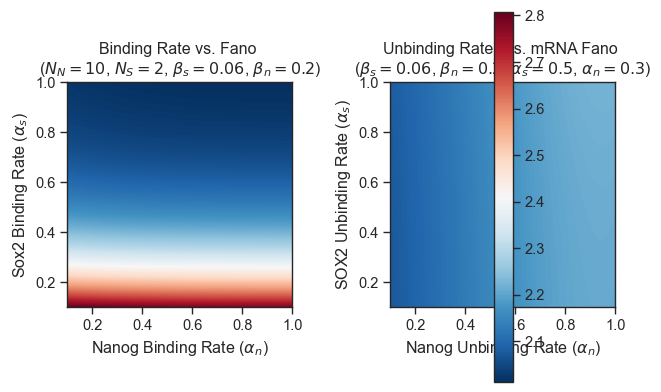

In [144]:
alpha_vals = np.logspace(-1, 0, 500)
beta_vals = np.logspace(-1, 0, 500)

X_alphas, Y_alphan = np.meshgrid(alpha_vals, alpha_vals)
X_betan, Y_betas = np.meshgrid(beta_vals, beta_vals)


Fy_fig1 = calculate_target_fano(alpha_n=X_alphas, alpha_s=Y_alphan, S_tot=S_tot, N_tot=N_tot)
Fy_fig2 = calculate_target_fano(beta_s=X_betan, beta_n=Y_betas, N_tot=N_tot, S_tot=S_tot)

sns.set_theme(style="ticks", context="paper", font_scale=1.2)
extent1 = [X_alphas.min(), X_alphas.max(), Y_alphan.min(), Y_alphan.max()]
extent2 = [X_betan.min(), X_betan.max(), Y_betas.min(), Y_betas.max()]
print(extent1, extent2)
fig, axes = plt.subplots(ncols=2, nrows=1)
vmin = min(Fy_fig1.min(), Fy_fig2.min())
vmax = max(Fy_fig1.max(), Fy_fig2.max())

plot_configs = [
    {
        "data": Fy_fig1,
        "extent": extent1,
        "xlabel": 'Nanog Binding Rate ($\\alpha_n$)',
        "ylabel": 'Sox2 Binding Rate ($\\alpha_s$)',
        "title": f'Binding Rate vs. Fano \n($N_N={N_N}$, $N_S={N_S}$, $\\beta_s = {beta_s}$, $\\beta_n = 0.2$)'
    },
    {
        "data": Fy_fig2,
        "extent": extent1,
        "xlabel": 'Nanog Unbinding Rate ($\\alpha_n$)',
        "ylabel": 'SOX2 Unbinding Rate ($\\alpha_s$)',
        "title": f'Unbinding Rates vs. mRNA Fano \n($\\beta_s = {beta_s}$, $\\beta_n = {beta_n}$, $\\alpha_s = {alpha_s}$, $\\alpha_n = {alpha_n}$)'
    }
]

for ax, config in zip(axes, plot_configs):
    im = ax.imshow(
        config["data"], 
        extent=config["extent"], 
        origin='lower', 
        cmap="RdBu_r",
        vmin=vmin,         
        vmax=vmax,         
    )
    ax.set_xlabel(config["xlabel"])
    ax.set_ylabel(config["ylabel"])
    ax.set_title(config["title"])

fig.colorbar(im, ax=axes.ravel().tolist())

plt.tight_layout()
plt.show()